In [6]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from pathlib import Path

In [9]:
BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"

train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"
sample_submission_path = DATA_DIR / "sample_submission.csv"


In [10]:
print(train_path)
print(test_path)
print(sample_submission_path)

print("Train exists:", train_path.exists())
print("Test exists:", test_path.exists())
print("Sample submission exists:", sample_submission_path.exists())

../data/train.csv
../data/test.csv
../data/sample_submission.csv
Train exists: True
Test exists: True
Sample submission exists: False


In [11]:
import os

os.listdir(DATA_DIR)

['test.csv', 'data_description.txt', 'train.csv', '.ipynb_checkpoints']

In [12]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

In [14]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (1460, 81)
Test shape: (1459, 80)


In [15]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [16]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [21]:
for column in train.columns:
    print(column)

Id
MSSubClass
MSZoning
LotFrontage
LotArea
Street
Alley
LotShape
LandContour
Utilities
LotConfig
LandSlope
Neighborhood
Condition1
Condition2
BldgType
HouseStyle
OverallQual
OverallCond
YearBuilt
YearRemodAdd
RoofStyle
RoofMatl
Exterior1st
Exterior2nd
MasVnrType
MasVnrArea
ExterQual
ExterCond
Foundation
BsmtQual
BsmtCond
BsmtExposure
BsmtFinType1
BsmtFinSF1
BsmtFinType2
BsmtFinSF2
BsmtUnfSF
TotalBsmtSF
Heating
HeatingQC
CentralAir
Electrical
1stFlrSF
2ndFlrSF
LowQualFinSF
GrLivArea
BsmtFullBath
BsmtHalfBath
FullBath
HalfBath
BedroomAbvGr
KitchenAbvGr
KitchenQual
TotRmsAbvGrd
Functional
Fireplaces
FireplaceQu
GarageType
GarageYrBlt
GarageFinish
GarageCars
GarageArea
GarageQual
GarageCond
PavedDrive
WoodDeckSF
OpenPorchSF
EnclosedPorch
3SsnPorch
ScreenPorch
PoolArea
PoolQC
Fence
MiscFeature
MiscVal
MoSold
YrSold
SaleType
SaleCondition
SalePrice


In [22]:
train["SalePrice"].head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

In [23]:
train["SalePrice"].describe() #Satış fiyatlarının genel dağılımı

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [26]:
missing_values = train.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

missing_values

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64

In [27]:
missing_percent = (train.isnull().sum() / len(train)) * 100
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percent": missing_percent
})

missing_summary

,missing_count,missing_percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [28]:
train_columns = set(train.columns)
test_columns = set(test.columns)

train_only_columns = train_columns - test_columns
test_only_columns = test_columns - train_columns

print("Only in train:", train_only_columns)
print("Only in test:", test_only_columns)

Only in train: {'SalePrice'}
Only in test: set()


In [29]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [30]:
numeric_columns = train.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = train.select_dtypes(include=["object"]).columns

print("Number of numeric columns:", len(numeric_columns))
print("Number of categorical columns:", len(categorical_columns))

Number of numeric columns: 38
Number of categorical columns: 43


In [31]:
numeric_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [32]:
categorical_columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [33]:
train["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

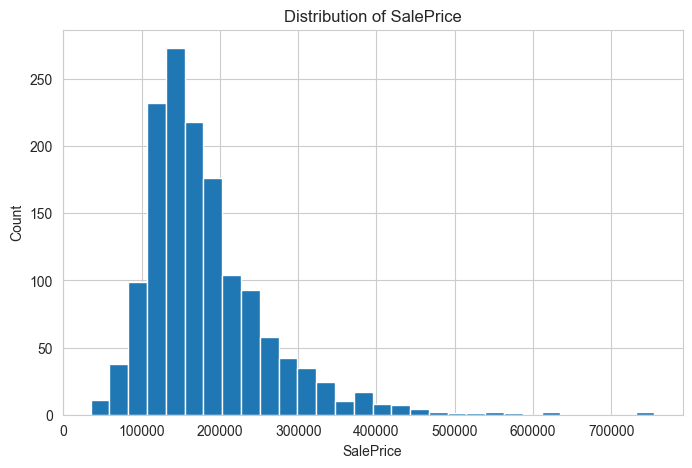

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(train["SalePrice"], bins=30)
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.title("Distribution of SalePrice")
plt.show()

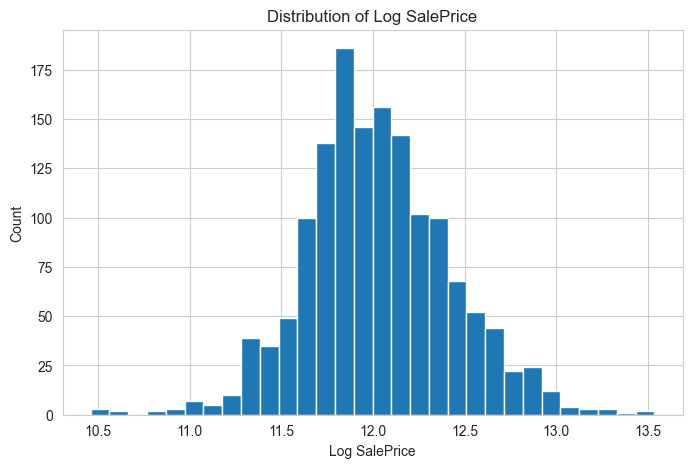

In [35]:
train["SalePrice_Log"] = np.log1p(train["SalePrice"])

plt.figure(figsize=(8, 5))
plt.hist(train["SalePrice_Log"], bins=30)
plt.xlabel("Log SalePrice")
plt.ylabel("Count")
plt.title("Distribution of Log SalePrice")
plt.show()

In [36]:
#skew dağılım çarpıklığını ölçer, 0'a yakınsa daha dengeli, pozitif büyükse sağa çarpık
print("SalePrice skewness:", train["SalePrice"].skew())
print("Log SalePrice skewness:", train["SalePrice_Log"].skew()) 

SalePrice skewness: 1.8828757597682129
Log SalePrice skewness: 0.12134661989685329


In [37]:
correlations = train[numeric_columns].corr()["SalePrice"].sort_values(ascending=False)
correlations.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

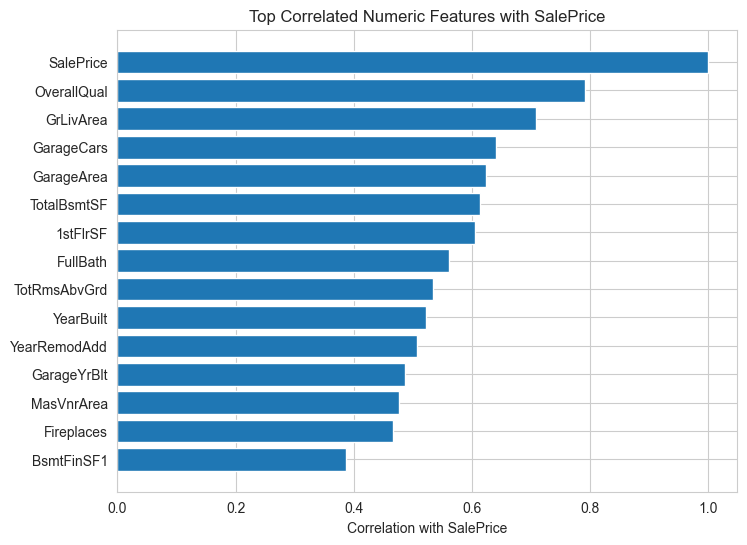

In [38]:
top_corr = correlations.head(15)

plt.figure(figsize=(8, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.xlabel("Correlation with SalePrice")
plt.title("Top Correlated Numeric Features with SalePrice")
plt.show()

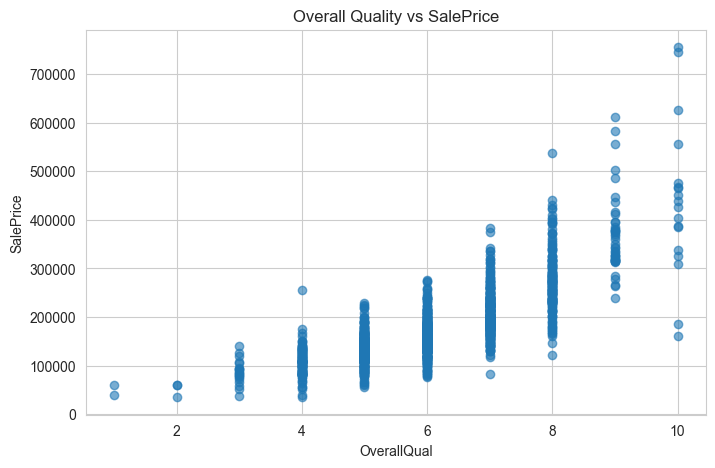

In [39]:
plt.figure(figsize=(8, 5))
plt.scatter(train["OverallQual"], train["SalePrice"], alpha=0.6)
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Overall Quality vs SalePrice")
plt.show()

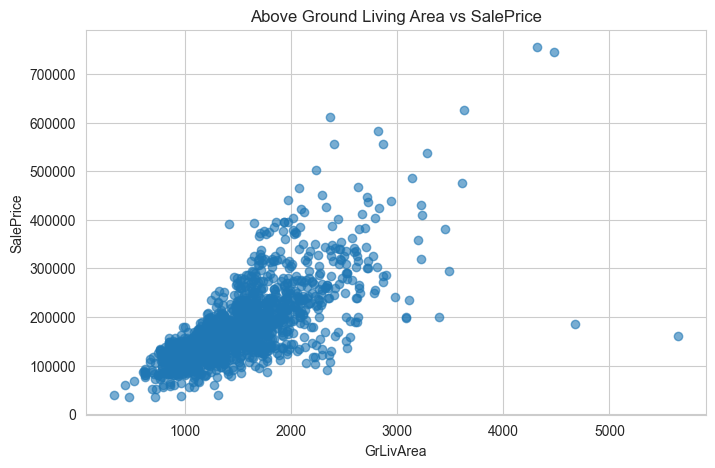

In [40]:
plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.6)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Above Ground Living Area vs SalePrice")
plt.show()

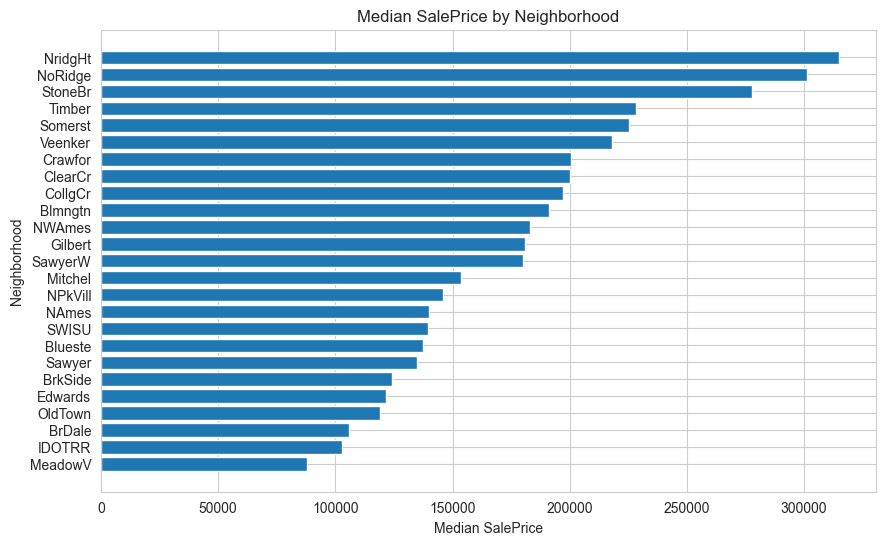

In [41]:
neighborhood_price = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(neighborhood_price.index[::-1], neighborhood_price.values[::-1])
plt.xlabel("Median SalePrice")
plt.ylabel("Neighborhood")
plt.title("Median SalePrice by Neighborhood")
plt.show()

In [42]:
target = "SalePrice"
log_target = "SalePrice_Log"
id_column = "Id"

numeric_features = [
    col for col in train.select_dtypes(include=["int64", "float64"]).columns
    if col not in [id_column, target, log_target]
]

categorical_features = train.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 36
Categorical features: 43


In [45]:
correlation_data = train[numeric_features + [target]]

correlations = correlation_data.corr()[target].sort_values(ascending=False)

top_correlations = correlations.drop(target).head(15)

top_correlations

OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

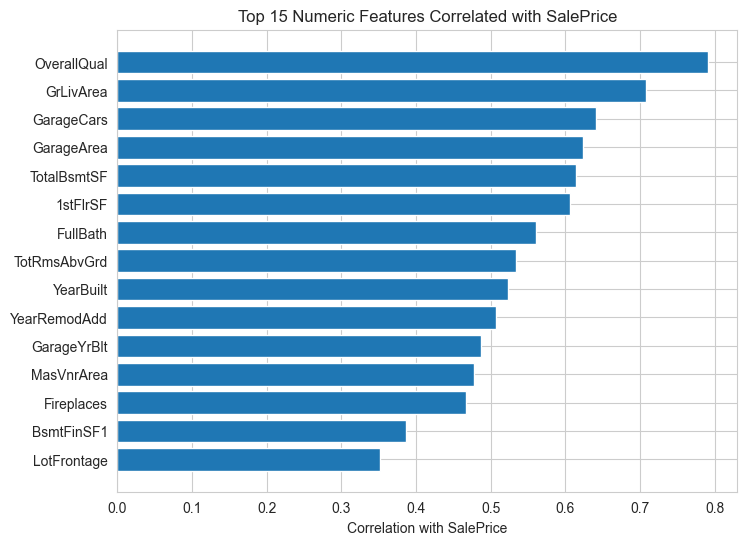

In [46]:
plt.figure(figsize=(8, 6))
plt.barh(top_correlations.index[::-1], top_correlations.values[::-1])
plt.xlabel("Correlation with SalePrice")
plt.title("Top 15 Numeric Features Correlated with SalePrice")
plt.show()

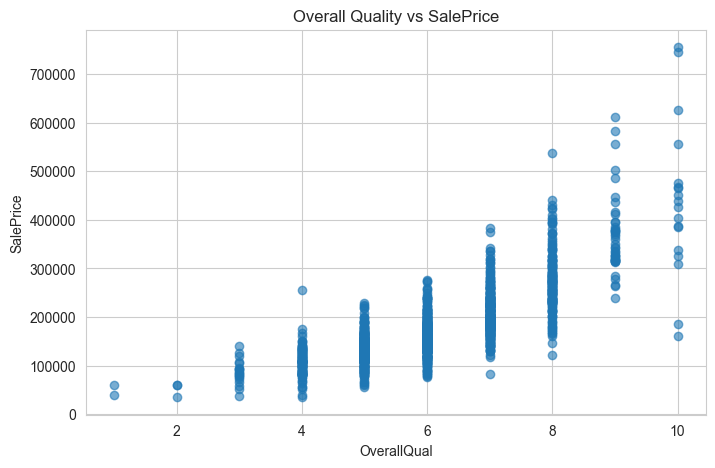

In [47]:
plt.figure(figsize=(8, 5))
plt.scatter(train["OverallQual"], train["SalePrice"], alpha=0.6)
plt.xlabel("OverallQual")
plt.ylabel("SalePrice")
plt.title("Overall Quality vs SalePrice")
plt.show()

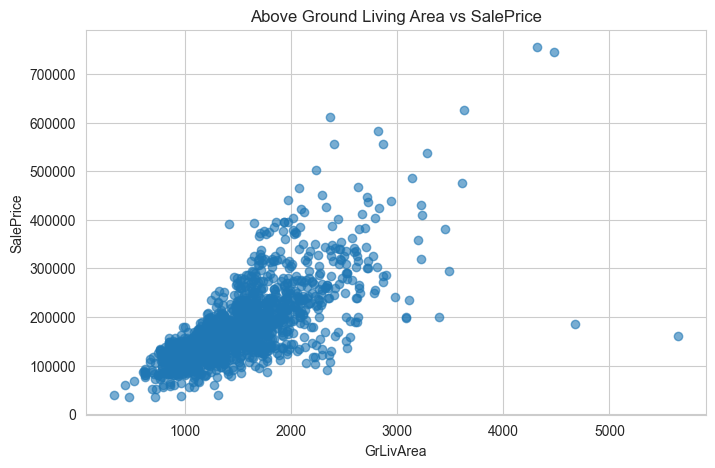

In [48]:
plt.figure(figsize=(8, 5))
plt.scatter(train["GrLivArea"], train["SalePrice"], alpha=0.6)
plt.xlabel("GrLivArea")
plt.ylabel("SalePrice")
plt.title("Above Ground Living Area vs SalePrice")
plt.show()

In [51]:
#aykırı değerleri gösterir
outliers = train[
    (train["GrLivArea"] > 4000) & 
    (train["SalePrice"] < 300000)
]

outliers[["Id", "GrLivArea", "SalePrice", "OverallQual", "Neighborhood"]]

,Id,GrLivArea,SalePrice,OverallQual,Neighborhood
523,524,4676,184750,10,Edwards
1298,1299,5642,160000,10,Edwards


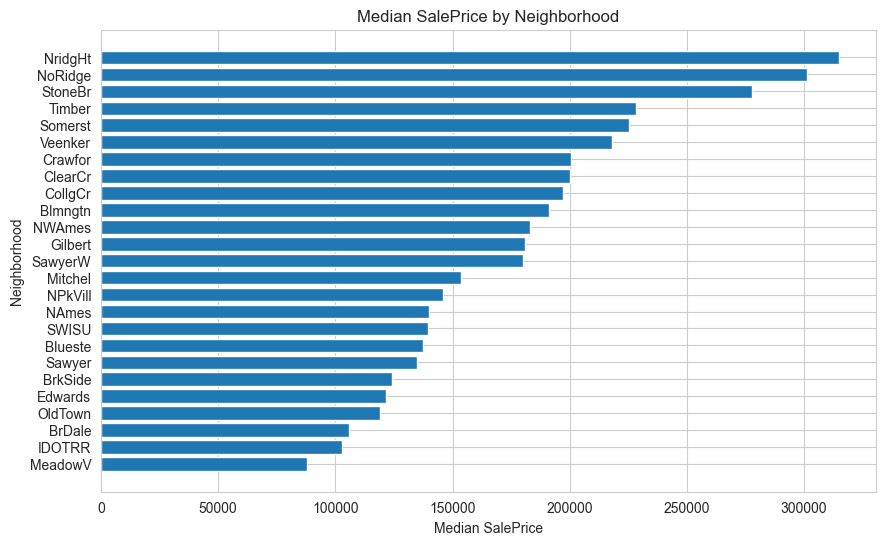

In [52]:
neighborhood_price = train.groupby("Neighborhood")["SalePrice"].median().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(neighborhood_price.index[::-1], neighborhood_price.values[::-1])
plt.xlabel("Median SalePrice")
plt.ylabel("Neighborhood")
plt.title("Median SalePrice by Neighborhood")
plt.show()

In [53]:
potential_outlier_ids = outliers["Id"].tolist()

potential_outlier_ids 

[524, 1299]

## Key Findings from Initial Data Understanding

- The training dataset contains 1460 rows and 81 columns.
- The test dataset contains 1459 rows and 80 columns.
- The only column available in the training set but not in the test set is `SalePrice`, which is the target variable.
- The dataset contains 38 numerical columns and 43 categorical columns before excluding ID and target-related columns.
- `SalePrice` is highly right-skewed with a skewness value of 1.88.
- After applying log transformation, the skewness decreased to 0.12, making the target distribution more suitable for modeling.
- The strongest numerical predictors of `SalePrice` are `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, and `1stFlrSF`.
- Two potential outliers were detected where `GrLivArea` is very high but `SalePrice` is relatively low.
- Missing values need to be handled carefully because some missing values represent the absence of a feature, such as no pool, no garage, no basement, or no fireplace.


## İlk Veri Anlama Aşamasından Temel Bulgular

* Eğitim veri seti 1460 satır ve 81 sütundan oluşmaktadır.
* Test veri seti 1459 satır ve 80 sütundan oluşmaktadır.
* Eğitim setinde olup test setinde bulunmayan tek sütun `SalePrice` sütunudur. Bu sütun, tahmin etmeye çalıştığımız hedef değişkendir.
* Veri seti, ID ve hedef değişkenle ilişkili sütunlar hariç tutulmadan önce 38 sayısal ve 43 kategorik sütun içermektedir.
* `SalePrice` değişkeni sağa çarpık bir dağılıma sahiptir ve çarpıklık değeri 1.88’dir.
* Log dönüşümü uygulandıktan sonra çarpıklık değeri 0.12’ye düşmüştür. Bu durum, hedef değişkenin modelleme için daha uygun bir dağılıma gelmesini sağlamıştır.
* `SalePrice` ile en güçlü ilişkiye sahip sayısal değişkenler `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF` ve `1stFlrSF` değişkenleridir.
* `GrLivArea` değeri çok yüksek olmasına rağmen `SalePrice` değeri görece düşük olan iki potansiyel aykırı değer tespit edilmiştir.
* Eksik değerler dikkatli şekilde ele alınmalıdır. Çünkü bazı eksik değerler gerçek bir veri eksikliğinden ziyade havuz, garaj, bodrum veya şömine gibi bir özelliğin bulunmadığını ifade etmektedir.
